In [16]:
import json
import time
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from xgboost import XGBRegressor
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

In [17]:
DATA_DIR = "../../datasets/5.0"  # adjust relative to notebook location

# --- load feature metadata ---
with open(f"{DATA_DIR}/features.json") as f:
    feature_metadata = json.load(f)

small_features = feature_metadata["feature_sets"]["small"]
target_col = "target"

# --- load train / validation parquet, only the columns we need ---
train = pd.read_parquet(
    f"{DATA_DIR}/train.parquet",
    columns=["era"] + small_features + [target_col],
)
val = pd.read_parquet(
    f"{DATA_DIR}/validation.parquet",
    columns=["era"] + small_features + [target_col],
)

# drop rows with no target (validation has some eras with NaN targets)
train = train.dropna(subset=[target_col])
val = val.dropna(subset=[target_col])

# xgboost (small Features + no era Boosting)

In [18]:
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
MODEL_CACHE = CACHE_DIR / "xgb_small_model.joblib"
PRED_CACHE = CACHE_DIR / "val_predictions_small.joblib"

# --- train xgboost on the small feature set (cached) ---
if MODEL_CACHE.exists():
    model = joblib.load(MODEL_CACHE)
else:
    model = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=5,
        colsample_bytree=0.1,
        tree_method="hist",
        n_jobs=-1,
    )
    model.fit(train[small_features], train[target_col])
    joblib.dump(model, MODEL_CACHE)

# --- predict on validation (cached) ---
if PRED_CACHE.exists():
    val["prediction"] = joblib.load(PRED_CACHE)
else:
    val["prediction"] = model.predict(val[small_features])
    joblib.dump(val["prediction"], PRED_CACHE)

In [19]:
# --- metrics ---
def feature_exposures(df, features, prediction_col="prediction"):
    exposures = [spearmanr(df[prediction_col], df[f])[0] for f in features]
    return np.array(exposures)


def max_feature_exposure(exposures):
    return np.max(np.abs(exposures))


def feature_exposure(exposures):
    return np.sqrt(np.mean(np.square(exposures)))


def era_spearman_corr(df, target_col="target", prediction_col="prediction"):
    return df.groupby("era").apply(
        lambda d: spearmanr(d[prediction_col], d[target_col])[0]
    )

In [20]:
era_corrs = era_spearman_corr(val, target_col=target_col)
print(f"Mean corr:   {era_corrs.mean():.4f}")
print(f"Std corr:    {era_corrs.std():.4f}")
print(f"Sharpe:      {era_corrs.mean() / era_corrs.std():.4f}")

exposures = feature_exposures(val, small_features)
print(f"Max feature exposure: {max_feature_exposure(exposures):.4f}")
print(f"Feature exposure:     {feature_exposure(exposures):.4f}")

Mean corr:   0.0174
Std corr:    0.0196
Sharpe:      0.8893
Max feature exposure: 0.2455
Feature exposure:     0.1336


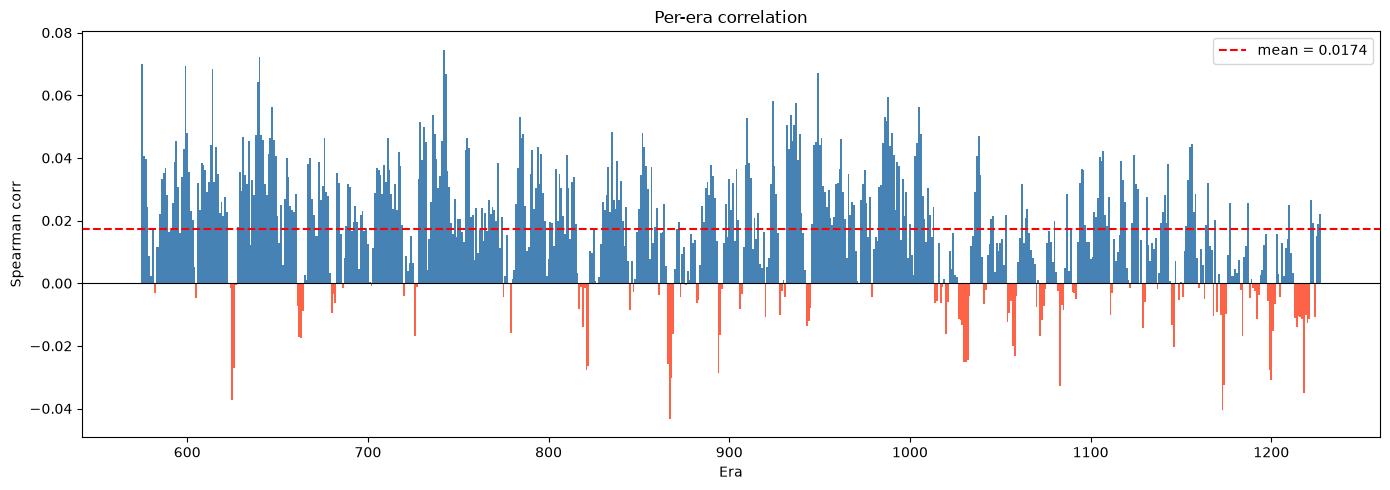

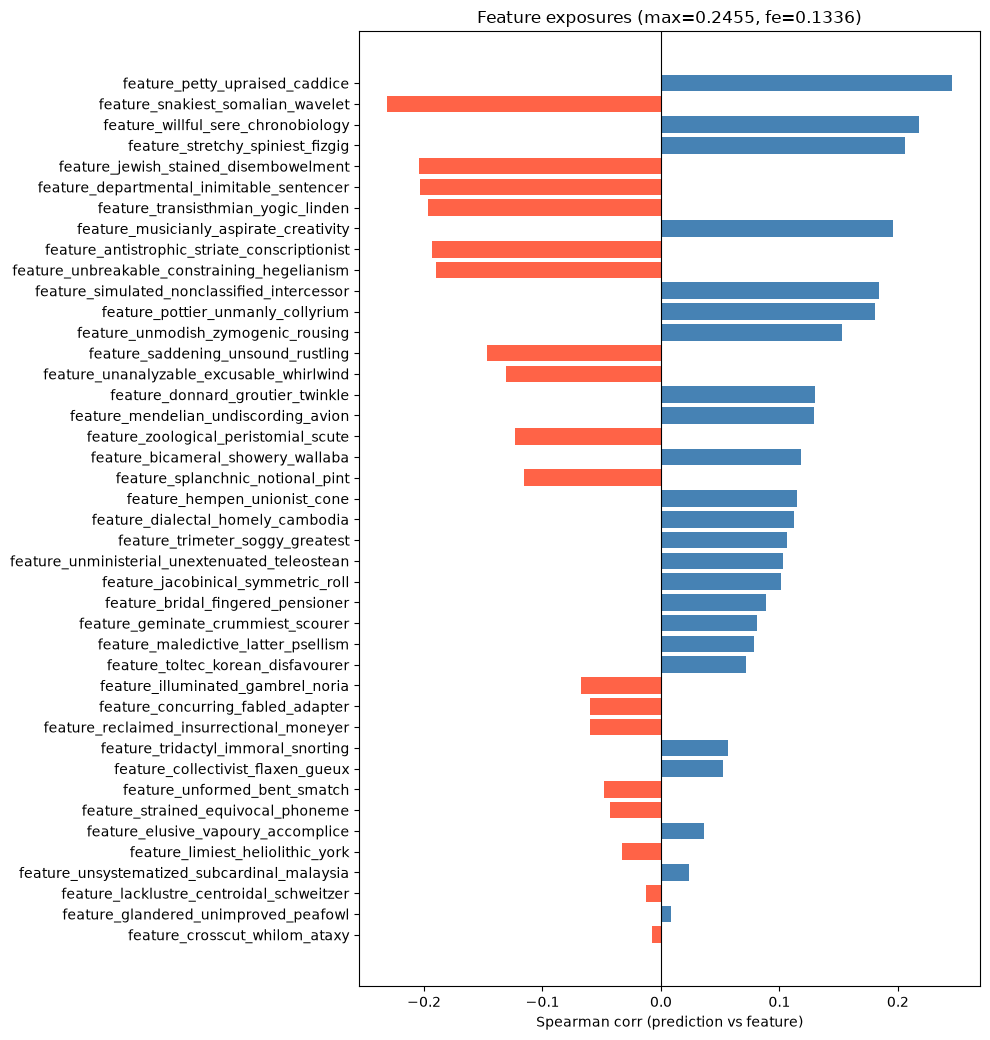

In [21]:
# --- per-era correlation plot ---
era_ints = era_corrs.index.astype(int)
order = np.argsort(era_ints)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["tomato" if c < 0 else "steelblue" for c in era_corrs.values[order]]
ax.bar(era_ints[order], era_corrs.values[order], color=colors, width=1.0)
ax.axhline(era_corrs.mean(), color="red", linestyle="--", label=f"mean = {era_corrs.mean():.4f}")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Era")
ax.set_ylabel("Spearman corr")
ax.set_title("Per-era correlation")
ax.legend()
plt.tight_layout()
plt.show()

# --- feature exposure bar plot ---
order = np.argsort(np.abs(exposures))[::-1]
sorted_features = [small_features[i] for i in order]
sorted_exposures = exposures[order]

fig, ax = plt.subplots(figsize=(10, len(small_features) * 0.25))
colors = ["tomato" if e < 0 else "steelblue" for e in sorted_exposures]
ax.barh(sorted_features, sorted_exposures, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("Spearman corr (prediction vs feature)")
ax.set_title(
    f"Feature exposures "
    f"(max={max_feature_exposure(exposures):.4f}, "
    f"fe={feature_exposure(exposures):.4f})"
)
plt.tight_layout()
plt.show()


# xgboost (small feature + era boosting)

In [22]:
def era_boost_train_with_history(
    X, y, era_col, proportion=0.5, trees_per_step=10, num_iters=200, snapshot_every=5,
    checkpoint_path=None,
):
    new_df = X.copy()
    new_df["target"] = y
    new_df["era"] = era_col

    start_iter = 0
    history = []
    if checkpoint_path is not None and checkpoint_path.exists():
        ckpt = joblib.load(checkpoint_path)
        model = ckpt["model"]
        start_iter = ckpt["iter"]
        history = ckpt["history"]
        total_trees = ckpt["total_trees"]
        print(f"resuming from checkpoint at iter {start_iter}/{num_iters}")
    else:
        model = XGBRegressor(
            n_estimators=trees_per_step,
            learning_rate=0.01,
            max_depth=5,
            colsample_bytree=0.1,
            tree_method="hist",
            n_jobs=-1,
        )
        model.fit(X, y)
        total_trees = trees_per_step

    era_scores = {}
    t_start = time.time()
    for i in range(start_iter, num_iters):
        t_iter = time.time()

        new_df["pred"] = model.predict(X)
        # groupby splits the frame once instead of re-scanning it per era
        # (this loop used to be the dominant cost: ~60s/iter vs ~5s/iter here
        # at 2.7M rows / 574 eras)
        era_scores = new_df.groupby("era").apply(
            lambda d: spearmanr(d["pred"], d["target"])[0]
        ).to_dict()

        if (i + 1) % snapshot_every == 0 or i == 0:
            for era, corr in era_scores.items():
                history.append({"iter": i + 1, "era": era, "corr": corr})

        worst_eras = sorted(era_scores, key=era_scores.get)[: int(len(era_scores) * proportion)]
        worst_df = new_df[new_df["era"].isin(worst_eras)]

        # xgb_model=booster continues training and adds `n_estimators` NEW trees on
        # top of whatever's already in the booster - it is not a target total. So
        # n_estimators must stay pinned at trees_per_step here; total_trees is a
        # separate running count kept just for logging/bookkeeping.
        booster = model.get_booster()
        model.n_estimators = trees_per_step
        model.fit(
            worst_df.drop(columns=["target", "era", "pred"]),
            worst_df["target"],
            xgb_model=booster,
        )
        total_trees += trees_per_step

        mean_corr = float(np.mean(list(era_scores.values())))
        print(
            f"iter {i + 1}/{num_iters}  mean_corr={mean_corr:.4f}  total_trees={total_trees}  "
            f"{time.time() - t_iter:.1f}s/iter  total={time.time() - t_start:.0f}s"
        )

        if checkpoint_path is not None and (i + 1) % snapshot_every == 0:
            joblib.dump(
                {"model": model, "iter": i + 1, "history": history, "total_trees": total_trees},
                checkpoint_path,
            )

    return model, era_scores, pd.DataFrame(history)

In [23]:
ERA_BOOST_MODEL_CACHE = CACHE_DIR / "xgb_small_era_boosted_model.joblib"
ERA_BOOST_SCORES_CACHE = CACHE_DIR / "era_boost_era_scores.joblib"
ERA_BOOST_PRED_CACHE = CACHE_DIR / "val_predictions_small_era_boosted.joblib"
ERA_BOOST_HISTORY_CACHE = CACHE_DIR / "era_boost_era_corr_history.parquet"
ERA_BOOST_CHECKPOINT = CACHE_DIR / "era_boost_checkpoint.joblib"

# trees_per_step=50, num_iters=40 -> 2000 total trees, matching xgb_small_model's n_estimators
if ERA_BOOST_MODEL_CACHE.exists():
    eb_model = joblib.load(ERA_BOOST_MODEL_CACHE)
    eb_era_scores = joblib.load(ERA_BOOST_SCORES_CACHE)
    history_df = pd.read_parquet(ERA_BOOST_HISTORY_CACHE)
else:
    eb_model, eb_era_scores, history_df = era_boost_train_with_history(
        train[small_features],
        train[target_col],
        train["era"],
        proportion=0.5,
        trees_per_step=50,
        num_iters=40,
        snapshot_every=5,
        checkpoint_path=ERA_BOOST_CHECKPOINT,
    )
    joblib.dump(eb_model, ERA_BOOST_MODEL_CACHE)
    joblib.dump(eb_era_scores, ERA_BOOST_SCORES_CACHE)
    history_df.to_parquet(ERA_BOOST_HISTORY_CACHE)
    ERA_BOOST_CHECKPOINT.unlink(missing_ok=True)

if ERA_BOOST_PRED_CACHE.exists():
    val["prediction_eb"] = joblib.load(ERA_BOOST_PRED_CACHE)
else:
    val["prediction_eb"] = eb_model.predict(val[small_features])
    joblib.dump(val["prediction_eb"], ERA_BOOST_PRED_CACHE)

iter 1/40  mean_corr=0.0460  total_trees=100  5.8s/iter  total=6s
iter 2/40  mean_corr=0.0544  total_trees=150  6.2s/iter  total=12s
iter 3/40  mean_corr=0.0578  total_trees=200  11.1s/iter  total=23s
iter 4/40  mean_corr=0.0599  total_trees=250  12.1s/iter  total=35s
iter 5/40  mean_corr=0.0615  total_trees=300  12.8s/iter  total=48s
iter 6/40  mean_corr=0.0622  total_trees=350  14.4s/iter  total=62s
iter 7/40  mean_corr=0.0628  total_trees=400  16.1s/iter  total=78s
iter 8/40  mean_corr=0.0640  total_trees=450  16.8s/iter  total=95s
iter 9/40  mean_corr=0.0644  total_trees=500  16.7s/iter  total=112s
iter 10/40  mean_corr=0.0653  total_trees=550  18.3s/iter  total=130s
iter 11/40  mean_corr=0.0660  total_trees=600  19.6s/iter  total=150s
iter 12/40  mean_corr=0.0667  total_trees=650  21.2s/iter  total=171s
iter 13/40  mean_corr=0.0673  total_trees=700  21.5s/iter  total=193s
iter 14/40  mean_corr=0.0679  total_trees=750  21.7s/iter  total=214s
iter 15/40  mean_corr=0.0683  total_tree

In [24]:
era_corrs = era_spearman_corr(val, target_col=target_col, prediction_col="prediction_eb")
print(f"Mean corr:   {era_corrs.mean():.4f}")
print(f"Std corr:    {era_corrs.std():.4f}")
print(f"Sharpe:      {era_corrs.mean() / era_corrs.std():.4f}")

exposures = feature_exposures(val, small_features, prediction_col="prediction_eb")
print(f"Max feature exposure: {max_feature_exposure(exposures):.4f}")
print(f"Feature exposure:     {feature_exposure(exposures):.4f}")

Mean corr:   0.0169
Std corr:    0.0189
Sharpe:      0.8948
Max feature exposure: 0.2455
Feature exposure:     0.1281


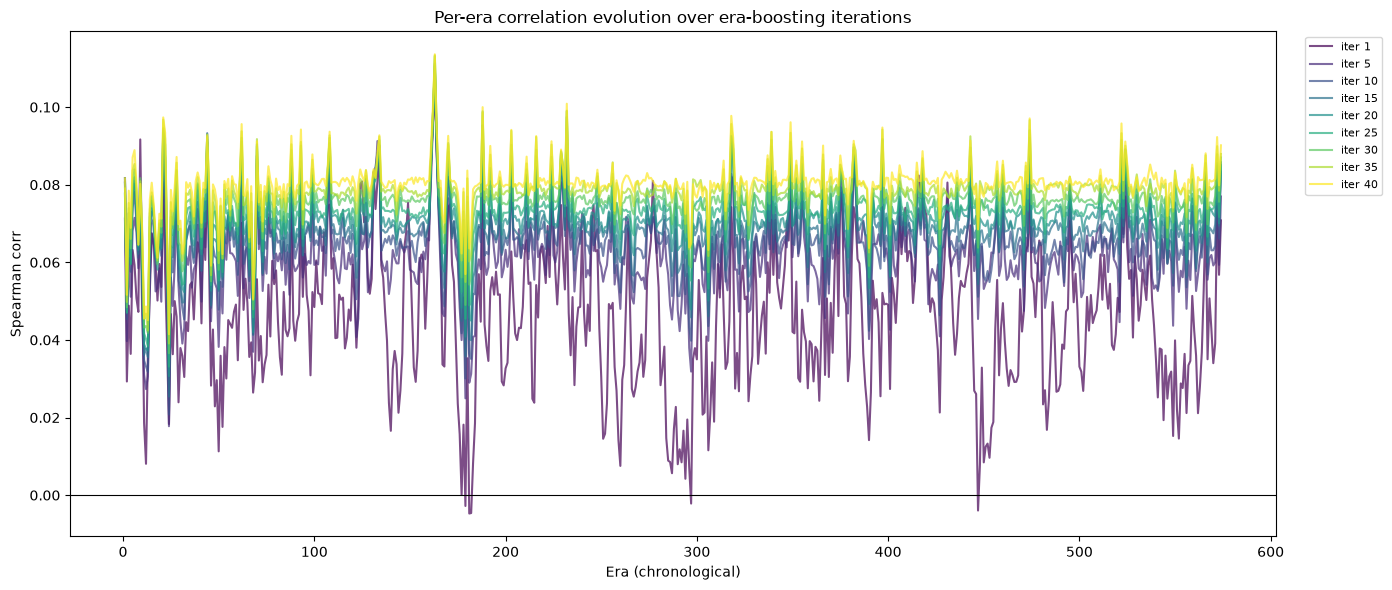

In [25]:
history_df["era_int"] = history_df["era"].astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
snapshot_iters = sorted(history_df["iter"].unique())
cmap = plt.cm.viridis

for idx, it in enumerate(snapshot_iters):
    sub = history_df[history_df["iter"] == it].sort_values("era_int")
    ax.plot(
        sub["era_int"], sub["corr"],
        label=f"iter {it}",
        color=cmap(idx / max(len(snapshot_iters) - 1, 1)),
        alpha=0.7,
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Era (chronological)")
ax.set_ylabel("Spearman corr")
ax.set_title("Per-era correlation evolution over era-boosting iterations")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

# Compare: normal vs era-boosted small model

Plain Sharpe (`mean / std`) treats a scattered set of bad eras the same as the same bad eras
clustered together, as long as the variance matches — it's blind to order. Smart Sharpe fixes
that by penalizing the denominator when the era-to-era corr sequence is autocorrelated (bad eras
following bad eras), per the ["Performance Stationarity"](https://forum.numer.ai/t/performance-stationarity/151)
formula: `mean(x) / (std(x) * autocorr_penalty(x))`.

In [26]:
def autocorr_penalty(x):
    """Lag-1 autocorrelation penalty on the denominator of Sharpe (per richai's
    Performance Stationarity post). 1.0 for a memoryless (uncorrelated) sequence,
    growing >1.0 as consecutive eras become more correlated (clumpier streaks)."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    p = np.corrcoef(x[:-1], x[1:])[0, 1]
    return np.sqrt(1 + 2 * np.sum([((n - i) / n) * p**i for i in range(1, n)]))


def smart_sharpe(x):
    x = np.asarray(x, dtype=float)
    return x.mean() / (x.std(ddof=1) * autocorr_penalty(x))


def summarize_era_corrs(era_corrs, label):
    penalty = autocorr_penalty(era_corrs.values)
    return {
        "model": label,
        "mean_corr": era_corrs.mean(),
        "std_corr": era_corrs.std(),
        "sharpe": era_corrs.mean() / era_corrs.std(),
        "autocorr_penalty": penalty,
        "smart_sharpe": smart_sharpe(era_corrs.values),
    }

In [27]:
# sort chronologically by era so lag-1 autocorrelation reflects actual era order,
# not string-sort order (groupby("era") sorts "10" before "2")
era_corrs_normal = era_spearman_corr(val, target_col=target_col, prediction_col="prediction")
era_corrs_normal = era_corrs_normal.loc[sorted(era_corrs_normal.index, key=int)]

era_corrs_eb = era_spearman_corr(val, target_col=target_col, prediction_col="prediction_eb")
era_corrs_eb = era_corrs_eb.loc[sorted(era_corrs_eb.index, key=int)]

comparison_df = pd.DataFrame([
    summarize_era_corrs(era_corrs_normal, "normal"),
    summarize_era_corrs(era_corrs_eb, "era_boosted"),
]).set_index("model")

comparison_df

,mean_corr,std_corr,sharpe,autocorr_penalty,smart_sharpe
model,,,,,
normal,0.017398,0.019564,0.889315,2.458700,0.361701
era_boosted,0.016875,0.018858,0.894836,2.445939,0.365845


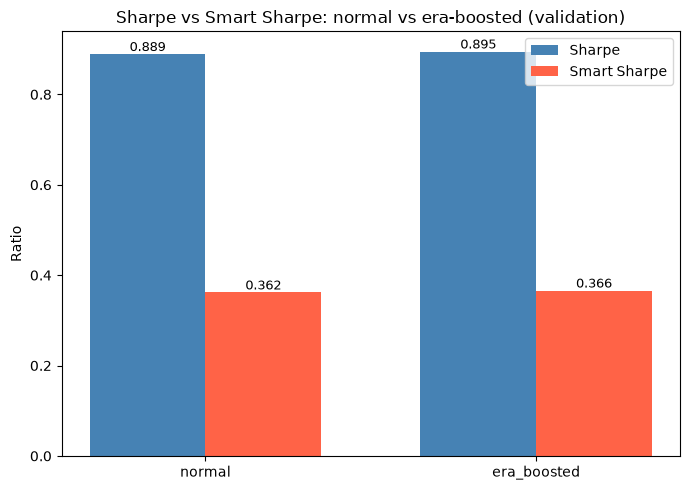

In [28]:
# --- sharpe vs smart sharpe, side by side ---
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width / 2, comparison_df["sharpe"], width, label="Sharpe", color="steelblue")
ax.bar(x + width / 2, comparison_df["smart_sharpe"], width, label="Smart Sharpe", color="tomato")

for i, (sharpe, smart) in enumerate(zip(comparison_df["sharpe"], comparison_df["smart_sharpe"])):
    ax.text(i - width / 2, sharpe, f"{sharpe:.3f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width / 2, smart, f"{smart:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.set_ylabel("Ratio")
ax.set_title("Sharpe vs Smart Sharpe: normal vs era-boosted (validation)")
ax.legend()
plt.tight_layout()
plt.show()